In [ ]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

Mounted at /content/drive


In [ ]:
base_path = '/content/drive/MyDrive/Colab Notebooks/'
df_orders = pd.read_csv(base_path + 'orders.csv')
df_items = pd.read_csv(base_path + 'order_items.csv')
df_sales = pd.read_csv(base_path + 'sales.csv')
df_reviews = pd.read_csv(base_path + 'reviews.csv')
df_returns = pd.read_csv(base_path + 'returns.csv')
df_web_traffic = pd.read_csv(base_path + 'web_traffic.csv')
df_shipments = pd.read_csv(base_path + 'shipments.csv')
df_products = pd.read_csv(base_path + 'products.csv')
df_promotions = pd.read_csv(base_path + 'promotions.csv')
df_payments = pd.read_csv(base_path + 'payments.csv')
df_customers = pd.read_csv(base_path + 'customers.csv')
df_inventory = pd.read_csv(base_path + 'inventory.csv')
df_geography = pd.read_csv(base_path + 'geography.csv')

/tmp/ipykernel_7312/2471928950.py:3: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df_items = pd.read_csv(base_path + 'order_items.csv')


/tmp/ipykernel_20726/953057703.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax0 = sns.barplot(data=rating_counts, x='rating', y='count', order=[5, 4, 3, 2, 1], palette=custom_colors, ax=axes[0])
/tmp/ipykernel_20726/953057703.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.barplot(data=category_rating, x='rating', y='category', palette=cat_colors, ax=axes[1])


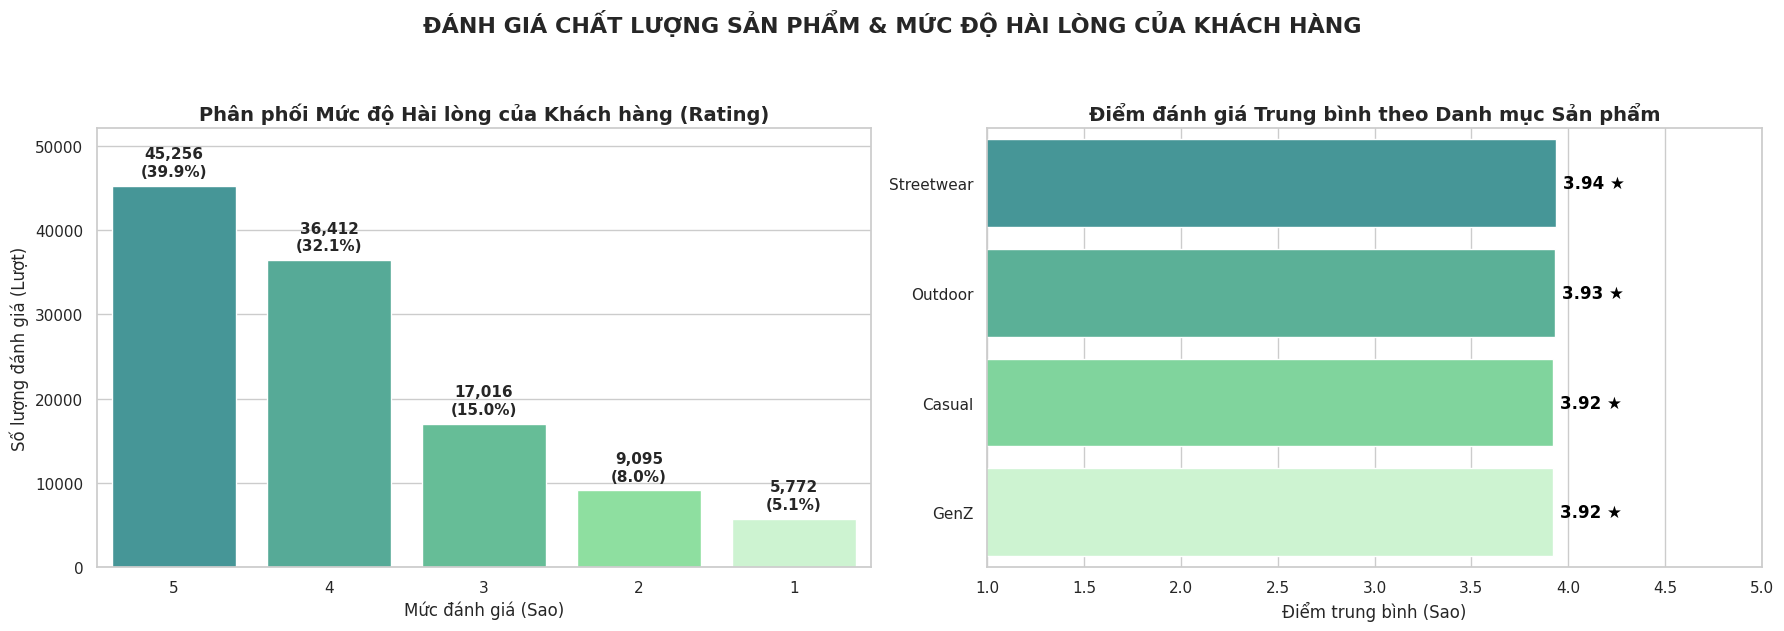

In [ ]:
rating_counts = df_reviews['rating'].value_counts().reset_index()
rating_counts.columns = ['rating', 'count']
total_reviews = rating_counts['count'].sum()

df_review_prod = pd.merge(df_reviews, df_products[['product_id', 'category']], on='product_id', how='inner')
category_rating = df_review_prod.groupby('category')['rating'].mean().reset_index().sort_values(by='rating', ascending=False)

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

custom_colors = ['#38A3A5', '#48B89F', '#57CC99', '#80ED99', '#C7F9CC']

ax0 = sns.barplot(data=rating_counts, x='rating', y='count', order=[5, 4, 3, 2, 1], palette=custom_colors, ax=axes[0])
ax0.set_title('Phân phối Mức độ Hài lòng của Khách hàng (Rating)', fontsize=14, fontweight='bold')
ax0.set_xlabel('Mức đánh giá (Sao)', fontsize=12)
ax0.set_ylabel('Số lượng đánh giá (Lượt)', fontsize=12)
ax0.set_ylim(0, rating_counts['count'].max() * 1.15)

for p in ax0.patches:
    h = p.get_height()
    if h > 0:
        ax0.annotate(f"{int(h):,}\n({(h / total_reviews) * 100:.1f}%)",
                     (p.get_x() + p.get_width() / 2., h),
                     ha='center', va='bottom', xytext=(0, 5), textcoords='offset points', fontweight='bold', fontsize=11)

cat_colors = sns.blend_palette(custom_colors, n_colors=len(category_rating))
ax1 = sns.barplot(data=category_rating, x='rating', y='category', palette=cat_colors, ax=axes[1])
ax1.set_title('Điểm đánh giá Trung bình theo Danh mục Sản phẩm', fontsize=14, fontweight='bold')
ax1.set_xlabel('Điểm trung bình (Sao)', fontsize=12)
ax1.set_ylabel('')
ax1.set_xlim(1, 5)

for p in ax1.patches:
    w = p.get_width()
    if w > 0:
        ax1.annotate(f"{w:.2f} ★",
                     (w, p.get_y() + p.get_height() / 2.),
                     ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontweight='bold', color='black')

plt.suptitle('ĐÁNH GIÁ CHẤT LƯỢNG SẢN PHẨM & MỨC ĐỘ HÀI LÒNG CỦA KHÁCH HÀNG', fontsize=16, fontweight='black', y=1.05)
plt.tight_layout()
plt.show()

THỐNG KÊ ĐIỂM ĐÁNH GIÁ TRUNG BÌNH THEO NĂM


,Year,Average_Rating,Review_Count
0,2012,3.95,4879
1,2013,3.93,13942
2,2014,3.92,14495
3,2015,3.94,14834
4,2016,3.93,14653
5,2017,3.94,13679
6,2018,3.93,12239
7,2019,3.93,7191
8,2020,3.98,6106
9,2021,3.92,5735


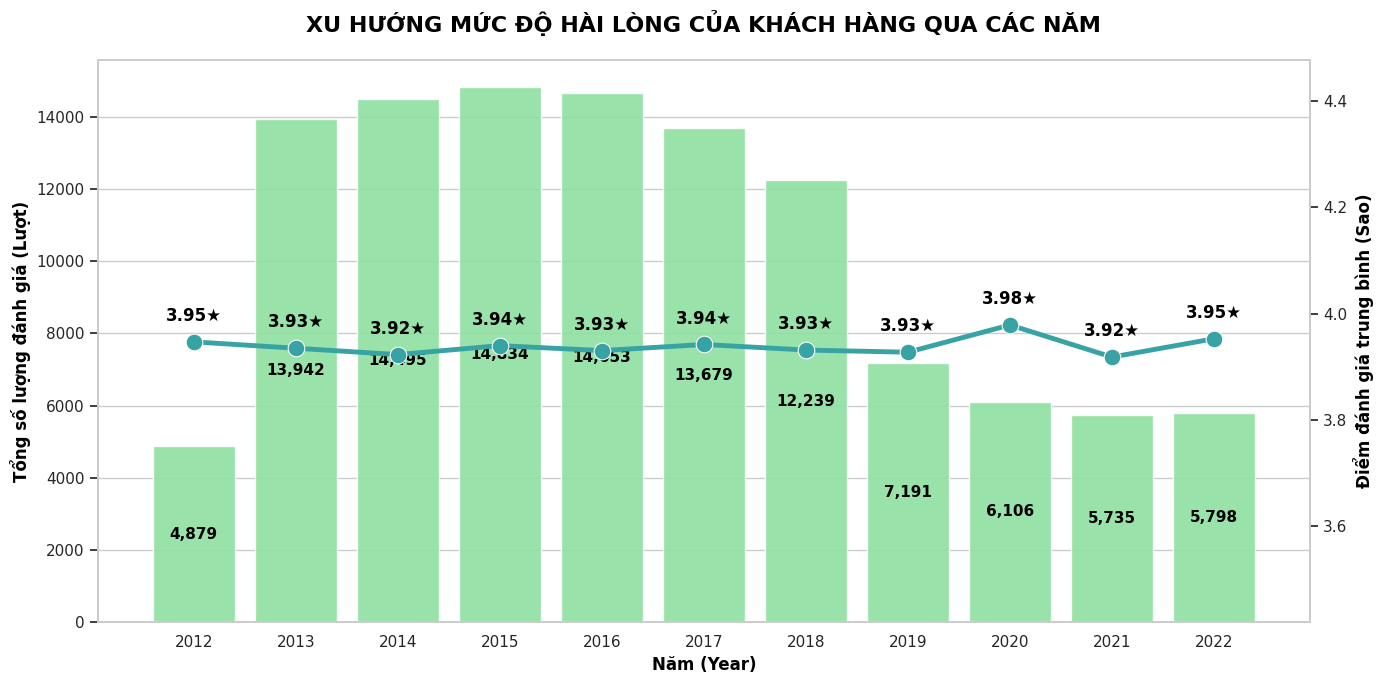

In [ ]:
df_reviews_clean = df_reviews.copy()
df_reviews_clean['Year'] = pd.to_datetime(df_reviews_clean['review_date'], errors='coerce').dt.year
df_reviews_clean = df_reviews_clean.dropna(subset=['Year'])
df_reviews_clean['Year'] = df_reviews_clean['Year'].astype(int)
df_reviews_clean['rating'] = pd.to_numeric(df_reviews_clean['rating'], errors='coerce')

yearly_rating = df_reviews_clean.groupby('Year').agg(
    Average_Rating=('rating', 'mean'),
    Review_Count=('rating', 'count')
).reset_index()

print("THỐNG KÊ ĐIỂM ĐÁNH GIÁ TRUNG BÌNH THEO NĂM")
display(yearly_rating.round(2))

sns.set_theme(style="whitegrid")
fig, ax1 = plt.subplots(figsize=(14, 7))

bar_color = '#80ED99'
line_color = '#38A3A5'

sns.barplot(data=yearly_rating, x='Year', y='Review_Count', color=bar_color, alpha=0.9, ax=ax1)
ax1.set_ylabel('Tổng số lượng đánh giá (Lượt)', fontsize=12, fontweight='bold', color='black')
ax1.set_xlabel('Năm (Year)', fontsize=12, fontweight='bold', color='black')

for p in ax1.patches:
    h = p.get_height()
    if h > 0:
        ax1.annotate(f"{int(h):,}", (p.get_x() + p.get_width() / 2., h / 2),
                     ha='center', va='center', color='black', fontweight='bold', fontsize=11)

ax2 = ax1.twinx()
sns.lineplot(data=yearly_rating, x=np.arange(len(yearly_rating)), y='Average_Rating',
             marker='o', linewidth=3.5, markersize=12, color=line_color, ax=ax2)

ax2.set_ylabel('Điểm đánh giá trung bình (Sao)', fontsize=12, fontweight='bold', color='black')
ax2.grid(False)

ymin = max(1, yearly_rating['Average_Rating'].min() - 0.5)
ymax = min(5, yearly_rating['Average_Rating'].max() + 0.5)
ax2.set_ylim(ymin, ymax)

for i, row in yearly_rating.iterrows():
    ax2.annotate(f"{row['Average_Rating']:.2f}★", (i, row['Average_Rating']),
                 textcoords="offset points", xytext=(0, 15), ha='center',
                 fontweight='bold', color='black', fontsize=12)

plt.title('XU HƯỚNG MỨC ĐỘ HÀI LÒNG CỦA KHÁCH HÀNG QUA CÁC NĂM', fontsize=16, fontweight='black', color='black', pad=20)
plt.tight_layout()
plt.show()

THỐNG KÊ CÁC NGUYÊN NHÂN TRẢ HÀNG


,Nguyên nhân trả hàng,Số lượng,Tỷ trọng (%)
0,Wrong\nSize,13967,34.97
1,Defective,8020,20.08
2,Not\nAs\nDescribed,7035,17.61
3,Changed\nMind,6931,17.35
4,Late\nDelivery,3986,9.98


/tmp/ipykernel_20726/1884088518.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=reason_counts, x='Nguyên nhân trả hàng', y='Số lượng', palette=custom_colors)


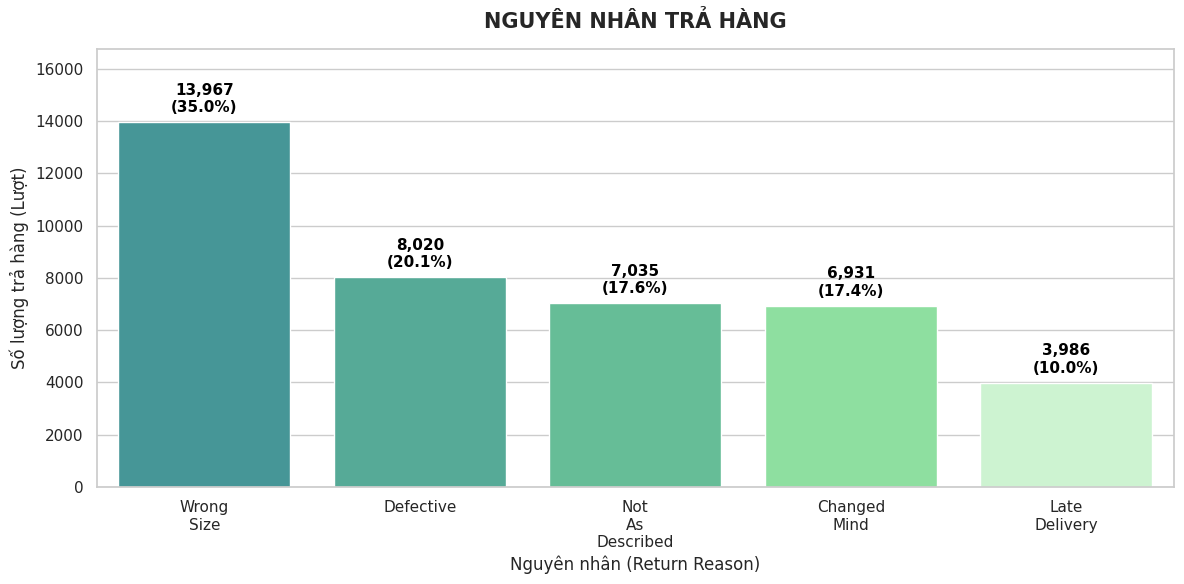

In [ ]:
reason_counts = df_returns['return_reason'].value_counts().reset_index()
reason_counts.columns = ['Nguyên nhân trả hàng', 'Số lượng']

reason_counts['Nguyên nhân trả hàng'] = reason_counts['Nguyên nhân trả hàng'].str.replace('_', '\n').str.title()

total_returns = reason_counts['Số lượng'].sum()
reason_counts['Tỷ trọng (%)'] = (reason_counts['Số lượng'] / total_returns * 100)

print("THỐNG KÊ CÁC NGUYÊN NHÂN TRẢ HÀNG")
display(reason_counts.round(2))

sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

custom_colors = ['#38A3A5', '#48B89F', '#57CC99', '#80ED99', '#C7F9CC']

ax = sns.barplot(data=reason_counts, x='Nguyên nhân trả hàng', y='Số lượng', palette=custom_colors)

plt.title('NGUYÊN NHÂN TRẢ HÀNG', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Nguyên nhân (Return Reason)', fontsize=12)
plt.ylabel('Số lượng trả hàng (Lượt)', fontsize=12)

plt.xticks(rotation=0, fontsize=11)

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        percentage = (height / total_returns) * 100
        ax.annotate(f"{int(height):,}\n({percentage:.1f}%)",
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', xytext=(0, 5), textcoords='offset points',
                    fontweight='bold', color='black', fontsize=11)

ax.set_ylim(0, reason_counts['Số lượng'].max() * 1.2)

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, export_text

features = ['stock_on_hand', 'units_received', 'units_sold', 'days_of_supply', 'sell_through_rate']

df_clean = df_inventory.dropna(subset=features + ['overstock_flag'])
X = df_clean[features]
y = df_clean['overstock_flag']

dt = DecisionTreeClassifier(max_depth=2, random_state=42)
dt.fit(X, y)

print("--- 1. LUẬT GẮN CỜ OVERSTOCK (TỰ ĐỘNG TRÍCH XUẤT) ---")
print(export_text(dt, feature_names=features))

print("\n--- 2. THỐNG KÊ ĐỂ XÁC NHẬN NGƯỠNG CHÍNH XÁC ---")
summary = df_clean.groupby('overstock_flag')[features].agg(['min', 'max']).T
display(summary)

--- 1. LUẬT GẮN CỜ OVERSTOCK (TỰ ĐỘNG TRÍCH XUẤT) ---
|--- days_of_supply <= 90.05
|   |--- class: 0
|--- days_of_supply >  90.05
|   |--- class: 1


--- 2. THỐNG KÊ ĐỂ XÁC NHẬN NGƯỠNG CHÍNH XÁC ---


overstock_flag                 0           1
stock_on_hand     min     3.0000      4.0000
                  max  1106.0000   2673.0000
units_received    min     1.0000      1.0000
                  max   817.0000    628.0000
units_sold        min     1.0000      1.0000
                  max   670.0000    496.0000
days_of_supply    min     5.2000     90.1000
                  max    90.0000  68100.0000
sell_through_rate min     0.2500      0.0004
                  max     0.8531      0.2498